In [ ]:
import os, sys

IS_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IS_COLAB:
    # Pin compatible versions and upgrade torchao to fix PEFT compatibility
    os.system('pip install -q numpy pyarrow transformers==4.44.0 datasets==2.19.0 peft==0.12.0 accelerate==0.33.0 torchao==0.16.0 python-dotenv')
    os.system('nvidia-smi')
    print('Packages installed. IMPORTANT: Go to Runtime → Restart session, then re-run all cells.')
else:
    print('Running locally — skipping pip install and nvidia-smi')


Packages installed. IMPORTANT: Go to Runtime → Restart session, then re-run all cells.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Option A: Upload unified_biology_dataset.json manually to /content/data/unified_biology_dataset.json
# Option B: Clone repo from GitHub
# !git clone https://github.com/<your-repo>/EduHinglish.git

Mounted at /content/drive


In [ ]:
import json
import random
from pathlib import Path
from collections import Counter
from transformers import AutoTokenizer
from datasets import Dataset, DatasetDict

# Path to the dataset in Google Drive
DATASET_PATH = Path("/content/drive/MyDrive/EduHinglish/data/unified_biology_dataset.json")
LID_OUTPUT_DIR = Path("/content/muril_lid_dataset")
MODEL_NAME = "google/muril-base-cased"
MAX_LENGTH = 128
SEED = 42

LID_LABEL2ID = {"HI": 0, "EN": 1, "NE": 2, "UNIV": 3, "MIX": 4}
LID_ID2LABEL = {v: k for k, v in LID_LABEL2ID.items()}
LID_LABELS = list(LID_LABEL2ID.keys())

_PUNCT_CHARS = frozenset(list(".,?!;:()-/") + ['"', "'", "–", "—", "…"])
_PUNCT_STRIP = "".join(_PUNCT_CHARS)

def strip_punct(word: str) -> str: return word.strip(_PUNCT_STRIP)
def is_punct_token(text: str) -> bool: return len(text) > 0 and all(ch in _PUNCT_CHARS for ch in text)

def lookup_label(word, labels_dict):
    cleaned = strip_punct(word)
    lbl = labels_dict.get(word) or labels_dict.get(word.lower()) or labels_dict.get(word.capitalize())
    if lbl: return lbl
    if cleaned != word:
        lbl = labels_dict.get(cleaned) or labels_dict.get(cleaned.lower()) or labels_dict.get(cleaned.capitalize())
        if lbl: return lbl
    if cleaned:
        cleaned_lower = cleaned.lower()
        for k, v in labels_dict.items():
            if strip_punct(k).lower() == cleaned_lower: return v
    if is_punct_token(word) or not cleaned: return "UNIV"
    return "EN"

print("Loading dataset...")
with open(DATASET_PATH, encoding="utf-8") as f:
    dataset = json.load(f)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
all_examples = []
label_counter = Counter()

for entry in dataset:
    hinglish = entry.get("hinglish_roman", "")
    labels_dict = entry.get("word_level_labels", {})
    if not hinglish or not labels_dict: continue

    words = hinglish.split()
    word_labels = [lookup_label(w, labels_dict) if lookup_label(w, labels_dict) in LID_LABEL2ID else "EN" for w in words]

    tokenized = tokenizer(words, is_split_into_words=True, max_length=MAX_LENGTH, truncation=True, padding=False)
    word_ids = tokenized.word_ids()

    aligned_labels = []
    previous_word_id = None
    for wid in word_ids:
        if wid is None: aligned_labels.append(-100)
        elif wid != previous_word_id:
            lbl_str = word_labels[wid]
            aligned_labels.append(LID_LABEL2ID[lbl_str])
            label_counter[lbl_str] += 1
        else: aligned_labels.append(-100)
        previous_word_id = wid

    all_examples.append({
        "input_ids": tokenized["input_ids"],
        "attention_mask": tokenized["attention_mask"],
        "labels": aligned_labels,
    })

random.seed(SEED)
random.shuffle(all_examples)
cut = max(1, int(len(all_examples) * 0.8))
train_examples, dev_examples = all_examples[:cut], all_examples[cut:]

def _to_dataset(examples):
    return Dataset.from_dict({
        "input_ids": [e["input_ids"] for e in examples],
        "attention_mask": [e["attention_mask"] for e in examples],
        "labels": [e["labels"] for e in examples]
    })

ds = DatasetDict({"train": _to_dataset(train_examples), "dev": _to_dataset(dev_examples)})
LID_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ds.save_to_disk(str(LID_OUTPUT_DIR))
print(f"Prepared LID data saved to {LID_OUTPUT_DIR}")

Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Saving the dataset (0/1 shards):   0%|          | 0/760 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/190 [00:00<?, ? examples/s]

Prepared LID data saved to /content/muril_lid_dataset


In [ ]:
import torch
import numpy as np
from transformers import AutoModelForTokenClassification, DataCollatorForTokenClassification, Trainer, TrainingArguments
from peft import LoraConfig, TaskType, get_peft_model
from datasets import load_from_disk

ds = load_from_disk(str(LID_OUTPUT_DIR))
train_ds, dev_ds = ds["train"], ds["dev"]

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME, num_labels=len(LID_LABEL2ID), id2label=LID_ID2LABEL, label2id=LID_LABEL2ID
)

lora_config = LoraConfig(
    task_type=TaskType.TOKEN_CLS, r=16, lora_alpha=32, lora_dropout=0.1, bias="none",
    target_modules=["query", "key", "value", "dense"]
)
model = get_peft_model(model, lora_config)

training_args = TrainingArguments(
    output_dir="/content/muril_lid_checkpoints",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    logging_steps=10,
    fp16=torch.cuda.is_available(),
    report_to="none",
    save_total_limit=2,
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer, padding=True, max_length=128)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=-1)

    true_labels, pred_labels = [], []
    for pred_seq, label_seq in zip(preds, labels):
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                true_labels.append(l)
                pred_labels.append(p)

    true_labels = np.array(true_labels)
    pred_labels = np.array(pred_labels)
    accuracy = (true_labels == pred_labels).mean() * 100

    label_metrics = {}
    for label_id in range(len(LID_LABEL2ID)):
        label_name = LID_ID2LABEL[label_id]
        tp = int(((pred_labels == label_id) & (true_labels == label_id)).sum())
        fp = int(((pred_labels == label_id) & (true_labels != label_id)).sum())
        fn = int(((pred_labels != label_id) & (true_labels == label_id)).sum())

        precision = (tp / (tp + fp) * 100) if (tp + fp) > 0 else 0.0
        recall    = (tp / (tp + fn) * 100) if (tp + fn) > 0 else 0.0
        f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

        label_metrics[label_name] = {"precision": precision, "recall": recall, "f1": f1, "support": tp + fn}

    return {"accuracy": accuracy, "label_metrics": label_metrics}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:488: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2888: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,Label Metrics
1,1.546400,1.453443,61.202660,"{'HI': {'precision': 61.20265972824516, 'recall': 100.0, 'f1': 75.93256814921091, 'support': 2117}, 'EN': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 1279}, 'NE': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 45}, 'UNIV': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 16}, 'MIX': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2}}"
2,1.337000,1.291592,64.064759,"{'HI': {'precision': 63.00595238095238, 'recall': 100.0, 'f1': 77.30509402957823, 'support': 2117}, 'EN': {'precision': 100.0, 'recall': 7.740422204847537, 'f1': 14.368650217706822, 'support': 1279}, 'NE': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 45}, 'UNIV': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 16}, 'MIX': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2}}"
3,1.175200,1.145927,96.906620,"{'HI': {'precision': 97.15073529411765, 'recall': 99.85829003306566, 'f1': 98.48590729093873, 'support': 2117}, 'EN': {'precision': 96.49259547934528, 'recall': 96.79437060203284, 'f1': 96.64324746291959, 'support': 1279}, 'NE': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 45}, 'UNIV': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 16}, 'MIX': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2}}"
4,1.069700,1.047481,97.398092,"{'HI': {'precision': 98.46010265982268, 'recall': 99.66934341048653, 'f1': 99.06103286384976, 'support': 2117}, 'EN': {'precision': 95.66869300911854, 'recall': 98.43627834245504, 'f1': 97.03275529865127, 'support': 1279}, 'NE': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 45}, 'UNIV': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 16}, 'MIX': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2}}"
5,0.987100,0.974831,97.195721,"{'HI': {'precision': 98.04832713754647, 'recall': 99.66934341048653, 'f1': 98.85219020847974, 'support': 2117}, 'EN': {'precision': 95.79188982402448, 'recall': 97.88897576231432, 'f1': 96.82907965970611, 'support': 1279}, 'NE': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 45}, 'UNIV': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 16}, 'MIX': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2}}"
6,0.935300,0.916961,97.542642,"{'HI': {'precision': 98.87429643527204, 'recall': 99.57487009919697, 'f1': 99.22334666980466, 'support': 2117}, 'EN': {'precision': 95.40316503391108, 'recall': 98.98358092259578, 'f1': 97.16039907904836, 'support': 1279}, 'NE': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 45}, 'UNIV': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 16}, 'MIX': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2}}"
7,0.885200,0.875801,97.600463,"{'HI': {'precision': 98.6007462686567, 'recall': 99.85829003306566, 'f1': 99.22553391222718, 'support': 2117}, 'EN': {'precision': 95.96958174904942, 'recall': 98.67083659108678, 'f1': 97.30146491904395, 'support': 1279}, 'NE': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 45}, 'UNIV': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 16}, 'MIX': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2}}"
8,0.854500,0.848286,97.542642,"{'HI': {'precision': 99.05882352941177, 'recall': 99.43316013226263, 'f1': 99.24563884959925, 'support': 2117}, 'EN': {'precision': 95.12743628185906, 'recall': 99.21813917122752, 'f1': 97.12973593570607, 'support': 1279}, 'NE': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 45}, 'UNIV': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 16}, 'MIX': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 2}}"
9,0.837300,0.831129,97.629373,"{'HI': {'precision': 98.78504672897196, 'recall': 99.85829003306566, 'f1': 99.31876908621093, 'support': 2117}, 'EN': {'precision': 95.75435936315391, 'recall': 98.74902267396403, 'f1': 97.22863741339492, 'support': 1279}, 'NE': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'support': 45}, 'UNIV': {'precision': 0.0, 'recall

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2888: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2888: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2888: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2888: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/usr

TrainOutput(global_step=480, training_loss=1.0688200891017914, metrics={'train_runtime': 52.7932, 'train_samples_per_second': 143.958, 'train_steps_per_second': 9.092, 'total_flos': 168473100128352.0, 'train_loss': 1.0688200891017914, 'epoch': 10.0})

In [ ]:
eval_result = trainer.evaluate()
print(f"Accuracy: {eval_result['eval_accuracy']:.2f}%")

label_metrics = eval_result.get("eval_label_metrics", {})
print("Per-label metrics:")
print(f"{'Label':>6s} | {'Precision':>10s} | {'Recall':>10s} | {'F1':>10s} | {'Support':>8s}")
for label_name in ["HI", "EN", "NE", "UNIV", "MIX"]:
    m = label_metrics.get(label_name, {})
    if m:
        print(f"{label_name:>6s} | {m.get('precision', 0):>9.1f}% | {m.get('recall', 0):>9.1f}% | {m.get('f1', 0):>9.1f}% | {m.get('support', 0):>8d}")

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2888: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Accuracy: 97.69%
Per-label metrics:
 Label |  Precision |     Recall |         F1 |  Support
    HI |      98.9% |      99.9% |      99.4% |     2117
    EN |      95.8% |      98.9% |      97.3% |     1279
    NE |       0.0% |       0.0% |       0.0% |       45
  UNIV |       0.0% |       0.0% |       0.0% |       16
   MIX |       0.0% |       0.0% |       0.0% |        2


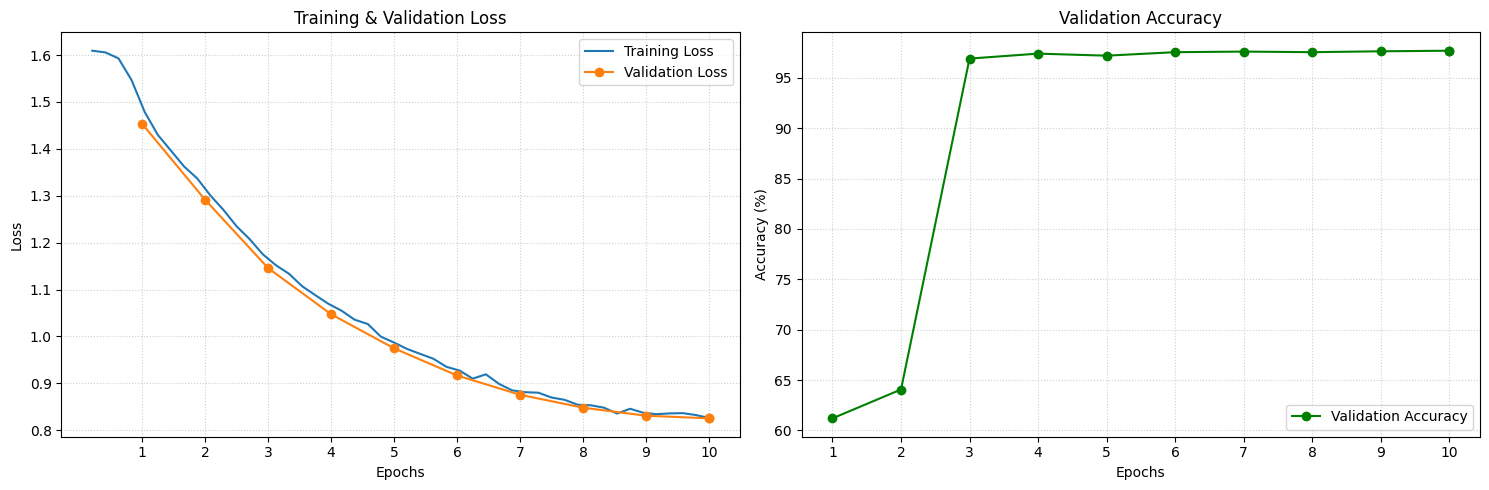

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

# 1. Extract loss/accuracy using 'epoch' instead of 'step'
train_loss = [log['loss'] for log in log_history if 'loss' in log]
train_epochs = [log['epoch'] for log in log_history if 'loss' in log]

eval_loss = [log['eval_loss'] for log in log_history if 'eval_loss' in log]
eval_epochs = [log['epoch'] for log in log_history if 'eval_loss' in log]
eval_metric = [log['eval_accuracy'] for log in log_history if 'eval_accuracy' in log]

# 2. Setup plotting
plt.figure(figsize=(15, 5))

# --- Subplot 1: Training & Validation Loss ---
plt.subplot(1, 2, 1)
plt.plot(train_epochs, train_loss, label='Training Loss', color='#1f77b4')
if eval_loss:
    plt.plot(eval_epochs, eval_loss, label='Validation Loss', color='#ff7f0e', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.xticks(range(1, 11)) # Forces integer ticks from 1 to 10
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# --- Subplot 2: Validation Accuracy ---
plt.subplot(1, 2, 2)
if eval_metric:
    plt.plot(eval_epochs, eval_metric, label='Validation Accuracy', color='green', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title('Validation Accuracy')
    plt.xticks(range(1, 11)) # Forces integer ticks from 1 to 10
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
import os
# Merge LoRA weights into base model before saving
merged_model = model.merge_and_unload()
# Fix non-contiguous tensors after LoRA merge
for param in merged_model.parameters():
    param.data = param.data.contiguous()
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/EduHinglish/models/muril_lid_v1"
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)

merged_model.save_pretrained(DRIVE_OUTPUT_DIR)
tokenizer.save_pretrained(DRIVE_OUTPUT_DIR)
print(f"Model saved to {DRIVE_OUTPUT_DIR}")

Model saved to /content/drive/MyDrive/EduHinglish/models/muril_lid_v1


In [ ]:
import re

LID_TESTS = [
    "Mitochondria ko cell ka powerhouse kehte hain.",
    "Sir, photosynthesis kaise hoti hai?",
    "DNA replication mein enzyme kya role play karta hai?",
    "Mendel ne pea plants par experiments kiye the.",
    "Yeh process anaerobic respiration kehlata hai.",
]

def predict_lid(text: str, model, tokenizer):
    words = re.findall(r"\w+|[^\w\s]", text)
    encoding = tokenizer(words, is_split_into_words=True, return_tensors="pt", truncation=True).to(model.device)

    with torch.no_grad():
        outputs = model(**encoding)
        predictions = torch.argmax(outputs.logits, dim=-1).squeeze(0).tolist()

    word_ids = encoding.word_ids()
    result = []
    current_word_idx = None

    for idx, word_idx in enumerate(word_ids):
        if word_idx is None: continue
        if word_idx != current_word_idx:
            current_word_idx = word_idx
            pred_label = model.config.id2label.get(predictions[idx], "O")
            result.append((words[word_idx], pred_label))
    return result

print("── MuRIL LID Predictions ──")
for sent in LID_TESTS:
    print(f'Input: "{sent}"')
    preds = predict_lid(sent, merged_model, tokenizer)
    for word, label in preds:
        spacing = "  " if len(label) == 2 else " "
        print(f"  {word:<12} → {label}{spacing}")
    print()

── MuRIL LID Predictions ──
Input: "Mitochondria ko cell ka powerhouse kehte hain."
  Mitochondria → EN  
  ko           → HI  
  cell         → EN  
  ka           → HI  
  powerhouse   → EN  
  kehte        → HI  
  hain         → HI  
  .            → HI  

Input: "Sir, photosynthesis kaise hoti hai?"
  Sir          → HI  
  ,            → HI  
  photosynthesis → EN  
  kaise        → HI  
  hoti         → HI  
  hai          → HI  
  ?            → HI  

Input: "DNA replication mein enzyme kya role play karta hai?"
  DNA          → EN  
  replication  → EN  
  mein         → HI  
  enzyme       → EN  
  kya          → HI  
  role         → EN  
  play         → EN  
  karta        → HI  
  hai          → HI  
  ?            → HI  

Input: "Mendel ne pea plants par experiments kiye the."
  Mendel       → EN  
  ne           → HI  
  pea          → EN  
  plants       → EN  
  par          → HI  
  experiments  → EN  
  kiye         → HI  
  the          → HI  
  .            → HI  
